# **Project 2: Model Comparison (Phase 2, Forest Cover Type Classification)**

David Almona \
DSC 340: Applied Machine Learning \
Spring 2026

---

**Dataset:** Forest Cover Type (30,000 rows, 54 features, 7-class classification) 

**Metric:** Macro F1 score

**Task:**  Predict the forest cover type (one of 7 tree species) from 54 features: 10 continuous variables and 44 binary indicators.



**Sections:**

01. Import Libraries
02. Data Loading and Brief EDA
03. Train/Test Split
04. Five-Model Pipeline
05. Results Table
06. Verdict
07. References and Acknowledgments

## 01. Import Libraries

In [31]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import time
import warnings

from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

warnings.filterwarnings('ignore')

## 02. Load Data & Exploratory Data Analysis

- Class distribution (bar chart with percentages). Discuss the imbalance.
- Feature characterization: describe the three feature groups (continuous, wilderness, soil). Identify sparse soil types.
- At least one interaction analysis (e.g., how does elevation distribution differ across
wilderness areas or cover types?).
- Correlation matrix for continuous features. Flag any strong correlations.

In [13]:
df = pd.read_csv('covtype_30k.csv')
df.head()

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
0,2728,63,3,182,12,1320,222,233,146,1947,...,0,0,0,0,0,0,0,0,0,2
1,3212,176,10,339,13,3316,225,246,152,451,...,0,0,0,0,0,0,0,0,0,2
2,3217,196,17,771,3,446,213,252,167,2523,...,0,0,0,0,0,0,0,0,0,2
3,2897,93,22,256,92,2684,248,200,70,1273,...,0,0,0,0,0,0,0,0,0,2
4,3044,47,12,582,190,6423,224,214,122,3829,...,0,0,0,0,0,0,0,0,0,2


In [14]:
# Check dataset dimensions and data types
print(f"Shape: {df.shape}")
print()
print(f"Data types:\n{df.dtypes}")

Shape: (30000, 55)

Data types:
Elevation                             int64
Aspect                                int64
Slope                                 int64
Horizontal_Distance_To_Hydrology      int64
Vertical_Distance_To_Hydrology        int64
Horizontal_Distance_To_Roadways       int64
Hillshade_9am                         int64
Hillshade_Noon                        int64
Hillshade_3pm                         int64
Horizontal_Distance_To_Fire_Points    int64
Wilderness_Area1                      int64
Wilderness_Area2                      int64
Wilderness_Area3                      int64
Wilderness_Area4                      int64
Soil_Type1                            int64
Soil_Type2                            int64
Soil_Type3                            int64
Soil_Type4                            int64
Soil_Type5                            int64
Soil_Type6                            int64
Soil_Type7                            int64
Soil_Type8                            int64


In [15]:
df.describe().round(2)

,Elevation,Aspect,Slope,Horizontal_Distance_To_Hydrology,Vertical_Distance_To_Hydrology,Horizontal_Distance_To_Roadways,Hillshade_9am,Hillshade_Noon,Hillshade_3pm,Horizontal_Distance_To_Fire_Points,...,Soil_Type32,Soil_Type33,Soil_Type34,Soil_Type35,Soil_Type36,Soil_Type37,Soil_Type38,Soil_Type39,Soil_Type40,Cover_Type
count,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,...,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00,30000.00
mean,2959.71,155.22,14.07,270.72,46.87,2356.56,212.27,223.37,142.47,1981.30,...,0.09,0.08,0.00,0.00,0.00,0.00,0.02,0.02,0.02,2.05
std,279.06,111.70,7.51,212.79,58.57,1560.68,26.77,19.65,38.14,1326.48,...,0.29,0.27,0.06,0.06,0.02,0.02,0.16,0.15,0.12,1.40
min,1876.00,0.00,0.00,0.00,-152.00,0.00,0.00,87.00,0.00,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
25%,2809.00,58.00,9.00,108.00,7.00,1106.75,199.00,213.00,119.00,1022.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
50%,2996.00,127.00,13.00,218.00,30.00,2012.00,218.00,226.00,143.00,1711.50,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00
75%,3164.00,260.00,18.00,390.00,69.00,3331.00,231.00,237.00,168.00,2550.25,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,2.00
max,3856.00,360.00,51.00,1397.00,550.00,7039.00,254.00,254.00,252.00,7141.00,...,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,1.00,7.00


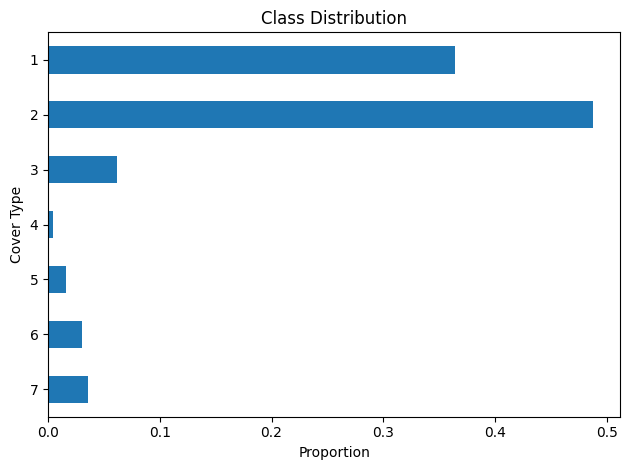

In [ ]:
# class distribution
target_col = df.columns[-1]
class_counts = df[target_col].value_counts(normalize = True).sort_index(ascending=False)

class_counts.plot(kind='barh')
plt.title('Class Distribution')
plt.ylabel('Cover Type')
plt.xlabel('Proportion')
plt.xticks(rotation = 0) 
plt.tight_layout()
plt.show()

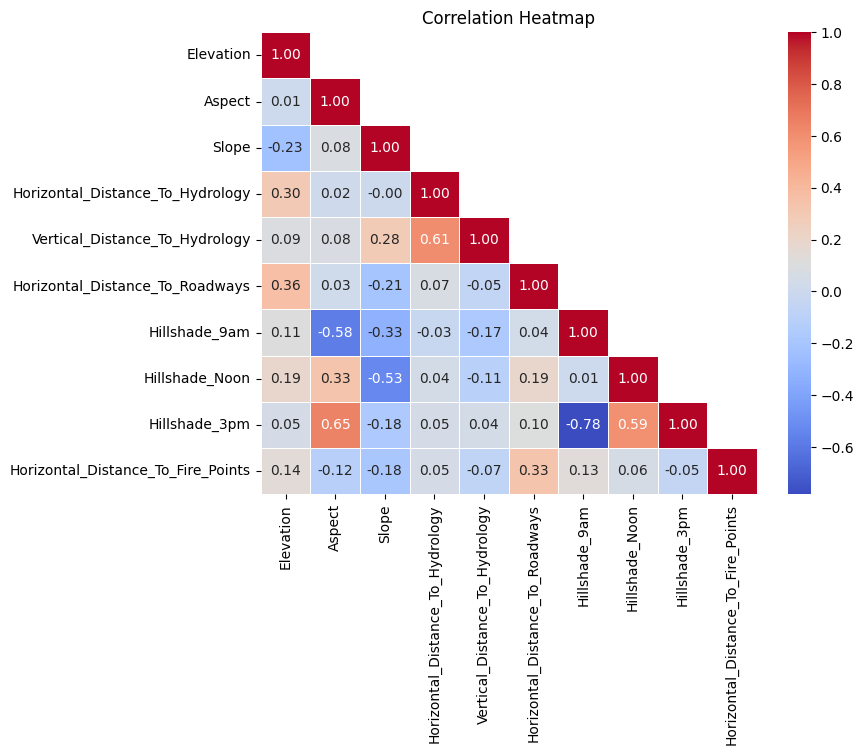

In [37]:
# correlation matrix for continuous features

binary_cols = [col for col in df.columns if df[col].nunique() == 2]
continuous_df = df.drop(columns = [*binary_cols, target_col, "Soil_Type15"])

matrix = continuous_df.corr()
mask = np.triu(np.ones_like(matrix, dtype = bool), k = 1)

plt.figure(figsize=(8,6))
sns.heatmap(matrix, mask = mask, annot = True, cmap = "coolwarm", fmt = ".2f", linewidths = 0.5)
plt.title("Correlation Heatmap")
plt.show()

references:

- Google's Gemini
- https://www.geeksforgeeks.org/data-science/create-a-correlation-matrix-using-python/